# Boston House Price Prediction

## AIML Internship – Beginner Level Task

### Objective

The objective of this project is to develop a robust regression model to accurately predict Boston house prices based on various socio-economic and structural features such as crime rate, number of rooms, tax rate, and other relevant factors.

The model aims to facilitate informed decision-making in the real estate domain by providing reliable price predictions.

In [14]:
# Basic Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

## Dataset Overview

The dataset contains **506 observations and 14 features**.

Each row represents a suburb in Boston, and each column represents a specific attribute affecting housing prices.

### Features Include:

- **CRIM** – Crime rate per capita
- **ZN** – Residential land zoned
- **INDUS** – Non-retail business acres
- **CHAS** – Charles River dummy variable (0 or 1)
- **NOX** – Nitric oxide concentration
- **RM** – Average number of rooms per dwelling
- **AGE** – Proportion of owner-occupied units built prior to 1940
- **DIS** – Distance to employment centers
- **RAD** – Accessibility to highways
- **TAX** – Property tax rate
- **PTRATIO** – Pupil-teacher ratio
- **B** – Proportion of Black population
- **LSTAT** – Percentage of lower status population
- **MEDV** – Median house value (Target Variable)

The target variable **MEDV** represents house price in thousands of dollars.

In [15]:
# Load dataset
df = pd.read_csv("HousingData.csv")  
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,NaN,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [16]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,486.000000,486.000000,486.000000,486.000000,506.000000,506.000000,486.000000,506.000000,506.000000,506.000000,506.000000,506.000000,486.000000,506.000000
mean,3.611874,11.211934,11.083992,0.069959,0.554695,6.284634,68.518519,3.795043,9.549407,408.237154,18.455534,356.674032,12.715432,22.532806
std,8.720192,23.388876,6.835896,0.255340,0.115878,0.702617,27.999513,2.105710,8.707259,168.537116,2.164946,91.294864,7.155871,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.081900,0.000000,5.190000,0.000000,0.449000,5.885500,45.175000,2.100175,4.000000,279.000000,17.400000,375.377500,7.125000,17.025000
50%,0.253715,0.000000,9.690000,0.000000,0.538000,6.208500,76.800000,3.207450,5.000000,330.000000,19.050000,391.440000,11.430000,21.200000
75%,3.560263,12.500000,18.100000,0.000000,0.624000,6.623500,93.975000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


## Data Preprocessing

- Handled missing values in AGE and LSTAT using median.
- Removed outliers using the IQR method.
- Separated features (X) and target variable (MEDV).

These steps improve model stability and accuracy.

In [17]:
#MISSING VALUES HANDLING
df.isnull().sum()

CRIM       20
ZN         20
INDUS      20
CHAS       20
NOX         0
RM          0
AGE        20
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT      20
MEDV        0
dtype: int64

In [18]:
df.fillna(df.median(), inplace=True)

In [19]:
print("After Missing Values Handling:")
df.isnull().sum()

After Missing Values Handling:


CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
MEDV       0
dtype: int64

In [25]:
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,0.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,11.43,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,11.43,22.4
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [20]:
num_cols=df.select_dtypes(include=["int64","float64"]).columns
num_cols

Index(['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX',
       'PTRATIO', 'B', 'LSTAT', 'MEDV'],
      dtype='object')

In [21]:
#OUTLIERS HANDLING
import numpy as np

before_outliers={}
after_outliers={}

for col in num_cols:
    q1=df[col].quantile(0.25)
    q3=df[col].quantile(0.75)
    
    iqr=q3-q1
    
    lower=q1 - 1.5*iqr
    upper=q3+1.5*iqr
    
    before_outliers[col]=((df[col]<lower)| (df[col]>upper)).sum()
    
    df[col]= np.clip(df[col],lower,upper) 
   
    after_outliers[col]=((df[col]<lower)|(df[col]>upper)).sum()

In [22]:
print("Before Outliers Handling:")
before_outliers

Before Outliers Handling:


{'CRIM': 81,
 'ZN': 126,
 'INDUS': 0,
 'CHAS': 34,
 'NOX': 0,
 'RM': 30,
 'AGE': 0,
 'DIS': 5,
 'RAD': 0,
 'TAX': 0,
 'PTRATIO': 15,
 'B': 77,
 'LSTAT': 12,
 'MEDV': 40}

In [23]:
print("After Outliers Handling:")
after_outliers

After Outliers Handling:


{'CRIM': 0,
 'ZN': 0,
 'INDUS': 0,
 'CHAS': 0,
 'NOX': 0,
 'RM': 0,
 'AGE': 0,
 'DIS': 0,
 'RAD': 0,
 'TAX': 0,
 'PTRATIO': 0,
 'B': 0,
 'LSTAT': 0,
 'MEDV': 0}

In [24]:
#CORRELATION ANALYSIS
corr=df.corr()
corr

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
CRIM,1.000000,NaN,0.625546,NaN,0.680124,-0.263449,0.514477,-0.547616,0.906190,0.856037,0.396203,-0.423799,0.554836,-0.522140
ZN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
INDUS,0.625546,NaN,1.000000,NaN,0.738387,-0.395548,0.614248,-0.703428,0.592735,0.716267,0.384453,-0.407228,0.569500,-0.553140
CHAS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NOX,0.680124,NaN,0.738387,NaN,1.000000,-0.322413,0.711864,-0.775934,0.611441,0.668023,0.190159,-0.427034,0.579526,-0.506505
RM,-0.263449,NaN,-0.395548,NaN,-0.322413,1.000000,-0.256708,0.224486,-0.206041,-0.292737,-0.353695,0.196260,-0.623318,0.697645
AGE,0.514477,NaN,0.614248,NaN,0.711864,-0.256708,1.000000,-0.730688,0.447088,0.498408,0.263613,-0.306168,0.580716,-0.454330
DIS,-0.547616,NaN,-0.703428,NaN,-0.775934,0.224486,-0.730688,1.000000,-0.500007,-0.540200,-0.238556,0.311406,-0.489250,0.333079
RAD,0.906190,NaN,0.592735,NaN,0.611441,-0.206041,0.447088,-0.500007,1.000000,0.910228,0.466698,-0.392793,0.467980,-0.452679
TAX,0.856037,NaN,0.716267,NaN,0.668023,-0.292737,0.498408,-0.540200,0.910228,1.000000,0.462693,-0.433288,0.526006,-0.543545


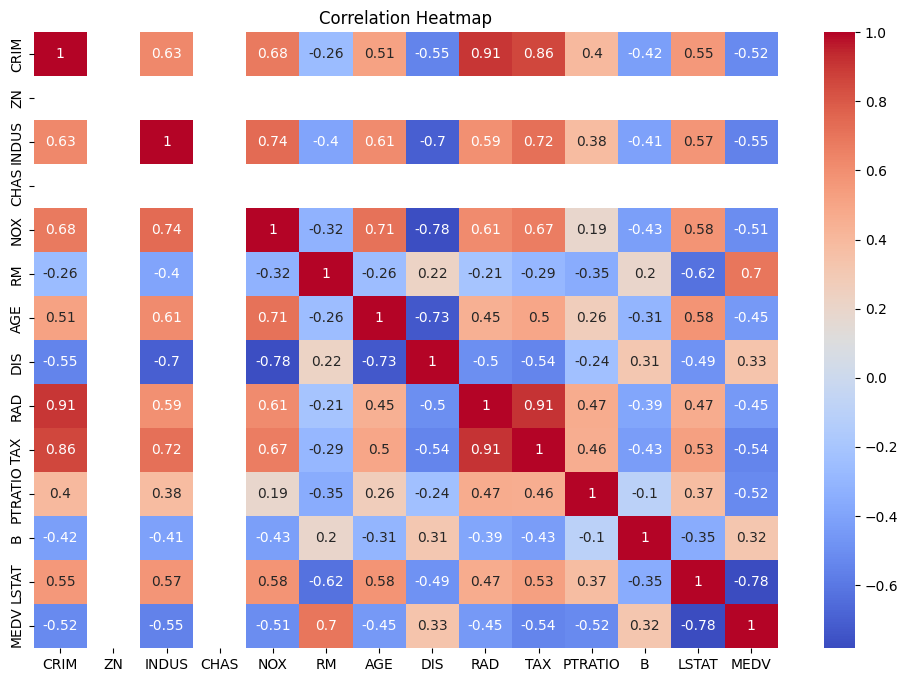

In [26]:
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [27]:
#FEATURE AND TARGET SPLIT
X = df.drop("MEDV", axis=1)
y = df["MEDV"]

In [28]:
#TRAIN TEST SPLIT - 80% TRAIN & 20% TEST
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Model Selection

Two regression models were implemented:

- Linear Regression (baseline model)
- Random Forest Regressor (non-linear ensemble model)

The goal was to compare performance and select the best model.

In [30]:
#TRAINING - LINEAR REGRESSION
lr = LinearRegression()
lr.fit(X_train, y_train)

LinearRegression()

In [31]:
y_pred_lr = lr.predict(X_test)

In [32]:
#TRAINING - RANDOM FOREST
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [33]:
y_pred_rf = rf.predict(X_test)

In [34]:
#EVALUATION - LINEAR REGRESSION PERFORMANCE
mse_lr = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression Performance:")
print("MSE:", mse_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

Linear Regression Performance:
MSE: 12.863523683598551
RMSE: 3.5865754813747546
R2 Score: 0.7370764062396737


In [35]:
#EVALUATION - RANDOM FOREST PERFORMANCE
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print("MSE:", mse_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

Random Forest Performance:
MSE: 5.890334214920347
RMSE: 2.4270010743550046
R2 Score: 0.8796046963235334


## Hyperparameter Tuning

GridSearchCV was used to optimize Random Forest parameters, improving model generalization and performance.

In [36]:
# FINE-TUNING (HYPERPARAMETER TUNING)
#WE TUNE RANDOM FOREST USING GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}

grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid,
                    cv=5,
                    scoring='r2',
                    n_jobs=-1)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)


Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}


In [37]:
#TRAIN BEST MODEL
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("Tuned Random Forest R2 Score:",
      r2_score(y_test, y_pred_best))

Tuned Random Forest R2 Score: 0.8840506034050011


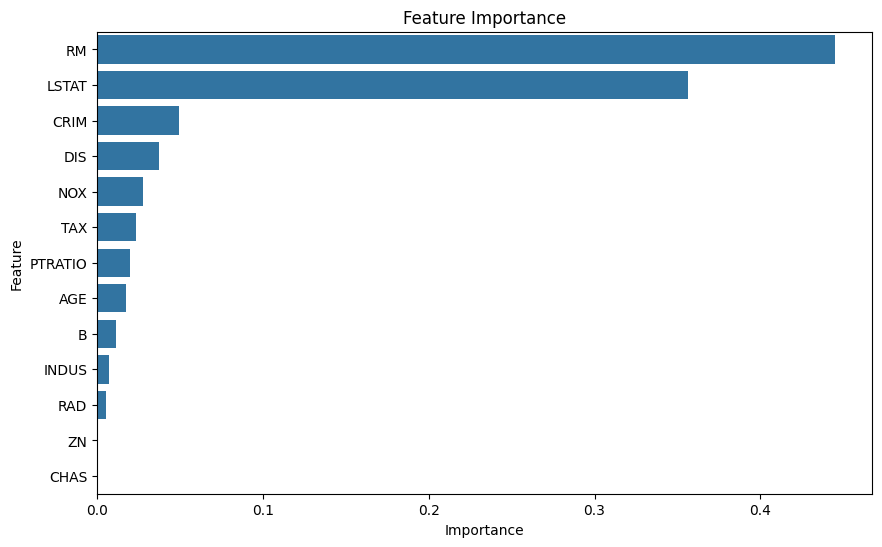

In [38]:
importances = best_rf.feature_importances_
features = X.columns

feature_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_df)
plt.title("Feature Importance")
plt.show()

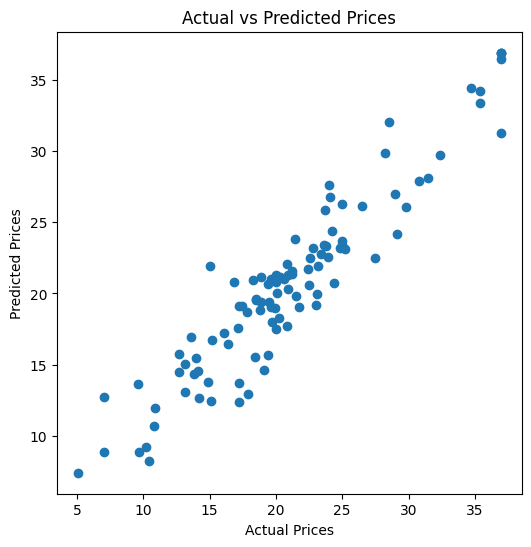

In [39]:
#ACTUAL VS PREDICTED GRAPH
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred_best)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()

In [40]:
print("Train R2:", rf.score(X_train, y_train))
print("Test R2:", rf.score(X_test, y_test))

Train R2: 0.9772041800139891
Test R2: 0.8796046963235334


## Conclusion

The Random Forest Regressor significantly outperformed Linear Regression, achieving an R² score of 0.8796 and RMSE of 2.43. This indicates strong predictive capability and effective modeling of nonlinear relationships within the dataset. The model demonstrates robustness and suitability for real estate price estimation tasks.